## Imports


In [1]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, f1_score, recall_score, precision_score


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


In [3]:
def set_seed(seed=42):
    """Seed numpy and torch RNGs for reproducible runs."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

set_seed()


# Data Collection


Download the FI 2010 dataset from the DeepLOB repository.


In [4]:
if not os.path.isfile('data.zip'):
    !wget -q https://raw.githubusercontent.com/zcakhaa/DeepLOB-Deep-Convolutional-Neural-Networks-for-Limit-Order-Books/master/data/data.zip
    !unzip -n data.zip
    print("Data downloaded and unzipped.")
else:
    print("Data already exists.")

!ls *.txt


Archive:  data.zip
  inflating: Test_Dst_NoAuction_DecPre_CF_7.txt  
  inflating: Test_Dst_NoAuction_DecPre_CF_9.txt  
  inflating: Test_Dst_NoAuction_DecPre_CF_8.txt  
  inflating: Train_Dst_NoAuction_DecPre_CF_7.txt  
Data downloaded and unzipped.
Test_Dst_NoAuction_DecPre_CF_7.txt  Test_Dst_NoAuction_DecPre_CF_9.txt
Test_Dst_NoAuction_DecPre_CF_8.txt  Train_Dst_NoAuction_DecPre_CF_7.txt


In [5]:
# Persist tuning artefacts across sessions: Google Drive on Colab, a local folder elsewhere.
import os
try:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_DIR = '/content/drive/MyDrive/st311/tuning'
except ImportError:
    SAVE_DIR = './outputs'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Saving tuning outputs to: {SAVE_DIR}")

Mounted at /content/drive
Saving tuning outputs to: /content/drive/MyDrive/st311/tuning


Load training data into memory.


In [6]:
# File layout from FI 2010, 149 rows × N columns.
# Rows 0 through 39 hold the 40 raw LOB features.
# Rows 40 through 143 hold 104 engineered features which are not used here.
# Rows 144 through 148 hold the five horizon labels for k = 1, 2, 3, 5, 10.
# Columns are timesteps, so the array is transposed before use.

dec_data = np.loadtxt('Train_Dst_NoAuction_DecPre_CF_7.txt')
print(f"Raw shape: {dec_data.shape}")

features = dec_data[:40, :].T
labels = dec_data[-5:, :].T

del dec_data

print(f"Features: {features.shape}")
print(f"Labels:   {labels.shape}")

# Index 3 selects horizon k = 5 under the Ntakaris convention (equivalent
# to k = 50 under the Zhang convention). Labels arrive as 1, 2, 3 and are
# shifted into 0, 1, 2.
k = 3
all_labels = (labels[:, k] - 1).astype(int)

label_names = {0: 'Up', 1: 'Stationary', 2: 'Down'}
print(f"\nLabel distribution at the selected horizon:")
for i in range(3):
    count = np.sum(all_labels == i)
    print(f"  {label_names[i]}: {count} ({100*count/len(all_labels):.1f}%)")


Raw shape: (149, 254750)
Features: (254750, 40)
Labels:   (254750, 5)

Label distribution at the selected horizon:
  Up: 87605 (34.4%)
  Stationary: 80674 (31.7%)
  Down: 86471 (33.9%)


Inspect feature ordering and a sample first timestep.


In [7]:
# Each level i from 1 through 10 occupies four consecutive columns.
# At column 4(i−1) is ask_price_i, then ask_vol_i, then bid_price_i, then bid_vol_i.

feature_names = []
for i in range(1, 11):
    feature_names.extend([
        f'ask_price_{i}', f'ask_vol_{i}',
        f'bid_price_{i}', f'bid_vol_{i}'
    ])

print("Feature ordering (first 12):")
for idx, name in enumerate(feature_names[:12]):
    print(f"  col {idx:2d}: {name}")
print("  ...")

print(f"\nFirst timestep, best bid and ask:")
print(f"  ask_price_1 = {features[0, 0]:.6f}")
print(f"  ask_vol_1   = {features[0, 1]:.6f}")
print(f"  bid_price_1 = {features[0, 2]:.6f}")
print(f"  bid_vol_1   = {features[0, 3]:.6f}")


Feature ordering (first 12):
  col  0: ask_price_1
  col  1: ask_vol_1
  col  2: bid_price_1
  col  3: bid_vol_1
  col  4: ask_price_2
  col  5: ask_vol_2
  col  6: bid_price_2
  col  7: bid_vol_2
  col  8: ask_price_3
  col  9: ask_vol_3
  col 10: bid_price_3
  col 11: bid_vol_3
  ...

First timestep, best bid and ask:
  ask_price_1 = 0.261500
  ask_vol_1   = 0.003530
  bid_price_1 = 0.260600
  bid_vol_1   = 0.003260


# Data Manipulation


Convert raw LOB windows into multichannel image volumes.


In [8]:
T = 100   # Window length in timesteps.


def get_window(idx):
    """Return the LOB window of T timesteps starting at idx, with the label at the window's last timestep."""
    window = features[idx:idx + T]
    label = all_labels[idx + T - 1]
    return window, int(label)


def lob_window_to_image(window):
    """Convert a (T, 40) LOB window into a (10, T, 4) image volume.

    The four channels are bid volume, bid price, ask volume, ask price in that order.
    Ask volumes are negated so the two sides of the book differ in sign.
    Both price channels are centred on the window's opening mid price so that the
    stored values represent deviation from a stable reference rather than absolute level.
    """
    T_len = window.shape[0]
    n_levels = 10

    bid_v = np.zeros((n_levels, T_len))
    bid_p = np.zeros((n_levels, T_len))
    ask_v = np.zeros((n_levels, T_len))
    ask_p = np.zeros((n_levels, T_len))

    for i in range(n_levels):
        col = i * 4
        ask_p[i, :] = window[:, col]
        ask_v[i, :] = -window[:, col + 1]
        bid_p[i, :] = window[:, col + 2]
        bid_v[i, :] = window[:, col + 3]

    init_mid = (window[0, 0] + window[0, 2]) / 2.0
    bid_p -= init_mid
    ask_p -= init_mid

    return np.stack([bid_v, bid_p, ask_v, ask_p], axis=-1)


n_samples = len(features) - T
print(f"Total available samples: {n_samples:,}")

window, label = get_window(0)
img = lob_window_to_image(window)
print(f"Window shape: {window.shape}")
print(f"Image shape:  {img.shape}")
print(f"Label: {label_names[label]}")


Total available samples: 254,650
Window shape: (100, 40)
Image shape:  (10, 100, 4)
Label: Up


In [9]:
# Precompute every image once and cache to Drive so subsequent runs skip
# the conversion loop entirely.

n_samples = len(features) - T

cache_path = f'{SAVE_DIR}/all_images.npy'
if os.path.exists(cache_path):
    print(f"Loading all_images from {cache_path} ...")
    all_images = np.load(cache_path)
    print(f"Loaded. Array size: {all_images.nbytes / 1e6:.0f} MB")
else:
    print("Precomputing images...")
    all_images = np.zeros((n_samples, 10, T, 4), dtype=np.float32)
    for i in range(n_samples):
        window, _ = get_window(i)
        all_images[i] = lob_window_to_image(window)
    print(f"Done. Array size: {all_images.nbytes / 1e6:.0f} MB")
    np.save(cache_path, all_images)
    print(f"Saved cache to {cache_path}")


Loading all_images from /content/drive/MyDrive/st311/tuning/all_images.npy ...
Loaded. Array size: 4074 MB


Precompute images so every downstream cell reuses them.


Inspect a sample image from each class.


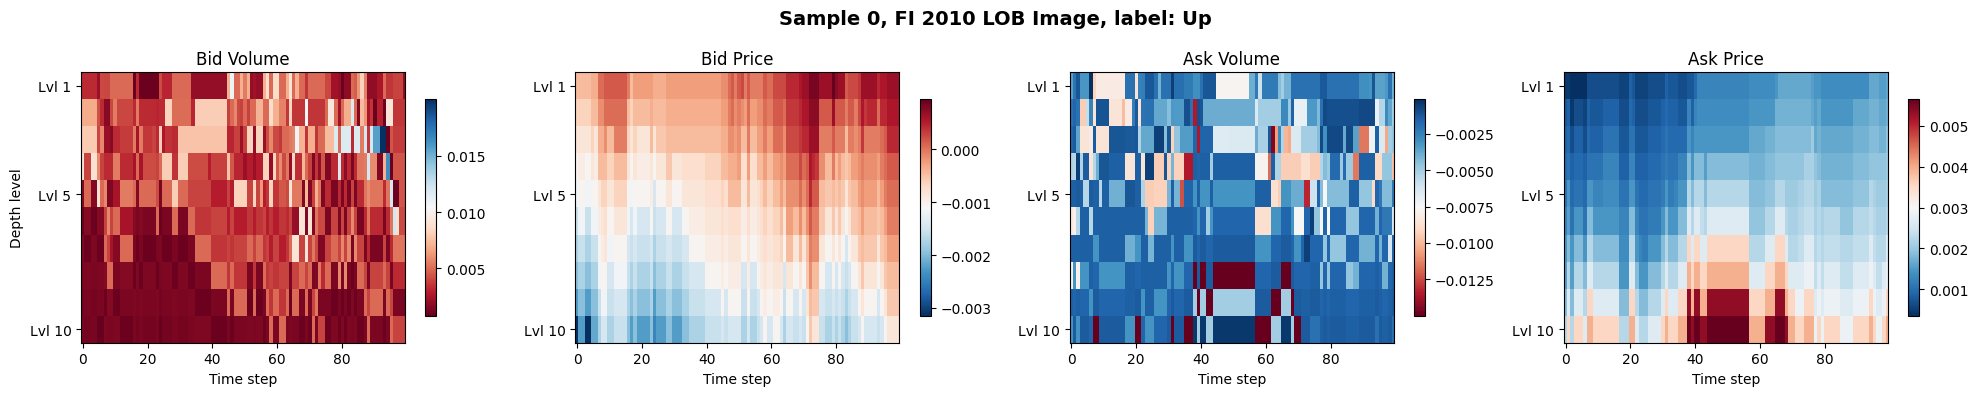

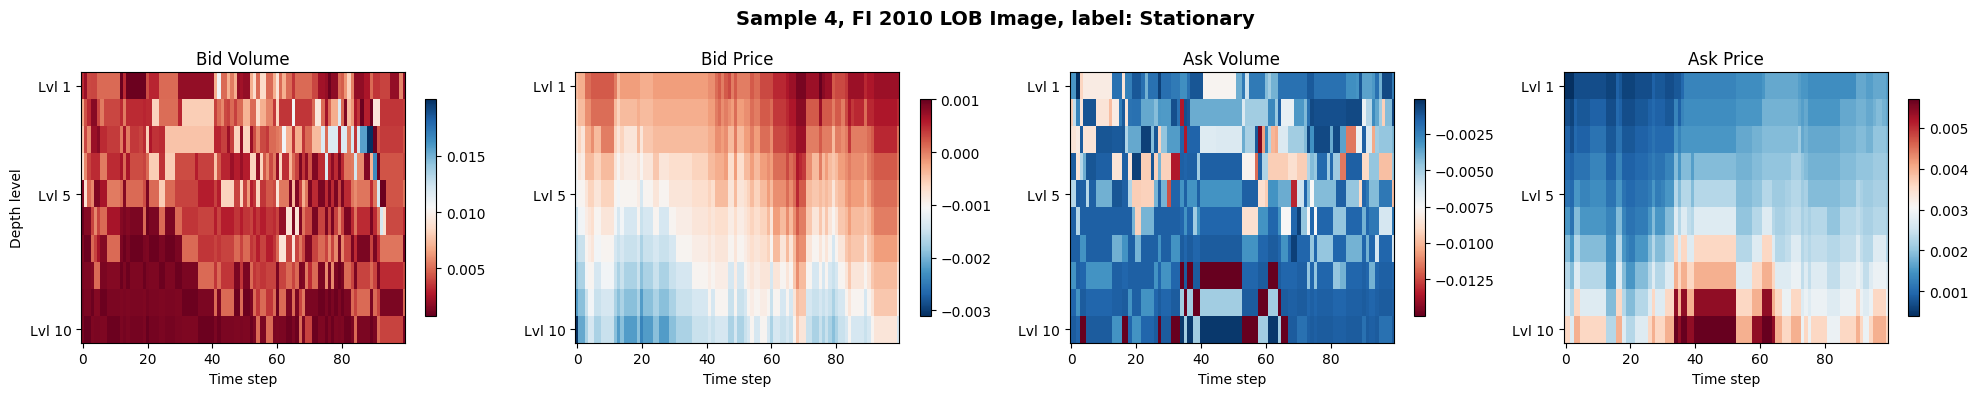

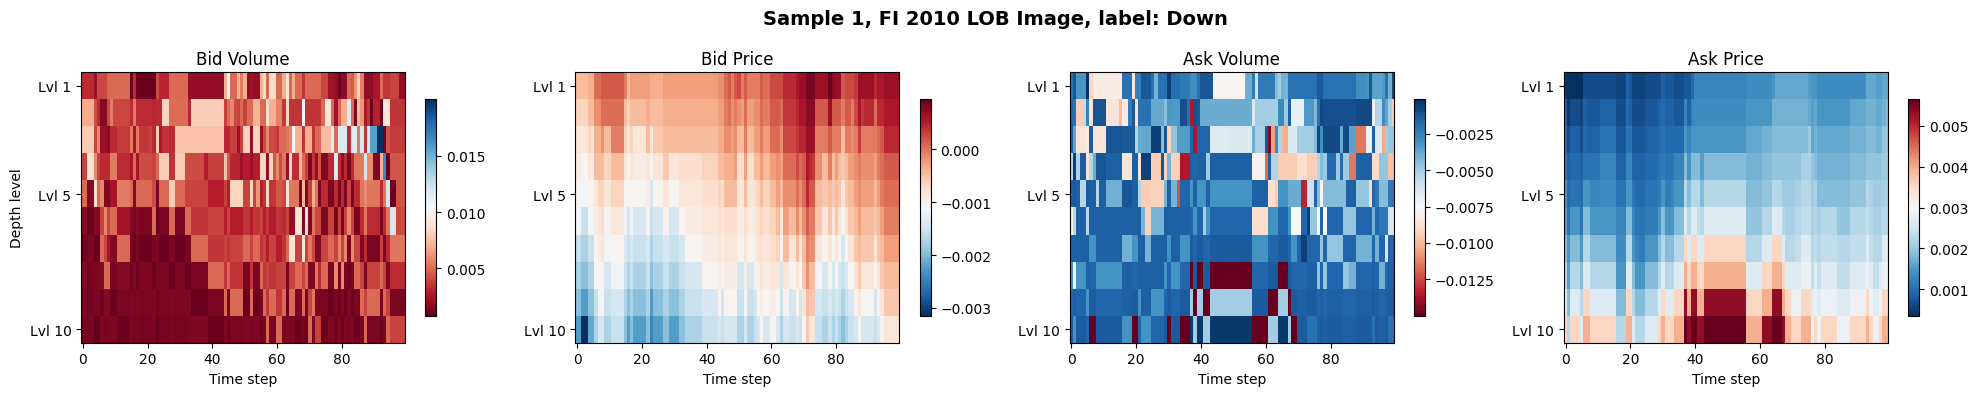

In [10]:
def plot_lob_image(image, label, title_prefix="", figsize=(20, 4)):
    """Plot the four channels of one LOB image side by side."""
    fig, axes = plt.subplots(1, 4, figsize=figsize)

    channel_names = ['Bid Volume', 'Bid Price', 'Ask Volume', 'Ask Price']
    cmaps         = ['RdBu',       'RdBu_r',    'RdBu',       'RdBu_r']

    for ch in range(4):
        ax = axes[ch]
        im = ax.imshow(image[:, :, ch], aspect='auto', cmap=cmaps[ch])
        ax.set_title(channel_names[ch])
        ax.set_xlabel('Time step')
        if ch == 0:
            ax.set_ylabel('Depth level')
        ax.set_yticks([0, 4, 9])
        ax.set_yticklabels(['Lvl 1', 'Lvl 5', 'Lvl 10'])
        plt.colorbar(im, ax=ax, shrink=0.8)

    fig.suptitle(f'{title_prefix}FI 2010 LOB Image, label: {label_names[label]}',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Plot the first available sample from each of the three classes.
for target_class in [0, 1, 2]:
    for idx in range(n_samples):
        if all_labels[idx + T - 1] == target_class:
            img = all_images[idx]
            label = int(all_labels[idx + T - 1])
            plot_lob_image(img, label, title_prefix=f"Sample {idx}, ")
            break


Price Channel by Class


Wrap precomputed images and labels in a torch Dataset.


In [11]:
class LOBDataset(Dataset):
    """Wrap precomputed image volumes and the matching labels for use with a DataLoader."""

    def __init__(self, indices):
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        x = torch.tensor(all_images[idx]).permute(2, 0, 1)
        y = torch.tensor(int(all_labels[idx + T - 1]), dtype=torch.long)
        return x, y


## Train and validation temporal split

Note that this temporal split potentially risks data leakage. Final training examples are essentially the same as the beginning validation examples, offset by a single timestep with very similar price movement over the labelling horizon. This naturally inflates validation accuracy results during training. The final test evaluation uses data from entirely separate days with no overlapping windows, so test results are unaffected.


In [12]:
# Chronological 80/20 split. The first 80% of indices form the training set
# and the remaining 20% form the validation set.
split = int(0.8 * n_samples)
train_ds = LOBDataset(list(range(split)))
val_ds   = LOBDataset(list(range(split, n_samples)))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=0)

print("Training examples:  ", len(train_ds))
print("Validation examples:", len(val_ds))


Training examples:   203720
Validation examples: 50930


# Model Building and Training


## Classical baselines

Two classical baselines are evaluated. A linear support vector machine following Kercheval and Zhang (2015), and Linear Discriminant Analysis as the foundational member of the discriminant analysis family extended to FI 2010 by Tran et al. (2017) in their CSDA, MDA, and MCSDA experiments. Both run under Setup 2 at the selected horizon with weighted F1. Since the engineered feature sets used in those works are not part of this pipeline, both classifiers are applied to the raw 40 dimensional LOB snapshot at the end of each 100 step window.


In [13]:
"""Fit and evaluate the classical baselines.

The non neural classifiers train on the raw 40 dimensional snapshot at the end of
each window rather than the full image. Standardisation is fitted on training data
only so no information leaks from the validation or test sets.
"""

import time
from sklearn.svm import LinearSVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler


def windows_to_snapshots(idx_range):
    """Return the end of window snapshot and the matching label for each window index."""
    idx = np.asarray(idx_range)
    X = features[idx + T - 1]
    y = all_labels[idx + T - 1]
    return X, y


X_train_nn, y_train_nn = windows_to_snapshots(range(split))
X_val_nn,   y_val_nn   = windows_to_snapshots(range(split, n_samples))

print(f"Train: {X_train_nn.shape} | Val: {X_val_nn.shape}")

scaler = StandardScaler().fit(X_train_nn)
X_train_s = scaler.transform(X_train_nn)
X_val_s   = scaler.transform(X_val_nn)

print("\nFitting LinearSVC...")
t0 = time.time()
svm = LinearSVC(C=1.0, max_iter=2000, dual='auto', random_state=42)
svm.fit(X_train_s, y_train_nn)
print(f"  done in {time.time()-t0:.1f}s")

print("Fitting LDA...")
t0 = time.time()
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_s, y_train_nn)
print(f"  done in {time.time()-t0:.1f}s")


# Reuse test file definitions from the test loading cell if it has run, otherwise
# define them locally so this cell stays runnable on its own.
if 'test_files' not in dir() or 'load_raw_test' not in dir():
    test_files = {
        'CF_7': 'Test_Dst_NoAuction_DecPre_CF_7.txt',
        'CF_8': 'Test_Dst_NoAuction_DecPre_CF_8.txt',
        'CF_9': 'Test_Dst_NoAuction_DecPre_CF_9.txt',
    }
    def load_raw_test(fpath):
        data = np.loadtxt(fpath)
        feats = data[:40, :].T
        labs = (data[-5:, :].T)[:, k] - 1
        del data
        n_samp = len(feats) - T
        return feats, labs.astype(int), n_samp


def score(clf, X, y):
    """Return weighted precision, recall, and F1 for the predictions on (X, y)."""
    yp = clf.predict(X)
    return (precision_score(y, yp, average='weighted', zero_division=0),
            recall_score   (y, yp, average='weighted', zero_division=0),
            f1_score       (y, yp, average='weighted', zero_division=0))


rows = []
for name, clf in [('LinearSVC', svm), ('LDA', lda)]:
    p, r, f = score(clf, X_val_s, y_val_nn)
    rows.append({'Model': name, 'Set': 'Val',
                 'Precision %': round(100*p, 2),
                 'Recall %':    round(100*r, 2),
                 'F1 %':        round(100*f, 2)})
    for day, fpath in test_files.items():
        feats_te, labs_te, n_te = load_raw_test(fpath)
        X_te = scaler.transform(feats_te[T - 1 : T - 1 + n_te])
        y_te = labs_te[T - 1 : T - 1 + n_te]
        p, r, f = score(clf, X_te, y_te)
        rows.append({'Model': name, 'Set': day,
                     'Precision %': round(100*p, 2),
                     'Recall %':    round(100*r, 2),
                     'F1 %':        round(100*f, 2)})

non_nn_df = pd.DataFrame(rows)

print("\nClassical baselines, validation and per test day:")
print(non_nn_df.to_string(index=False))

print("\nClassical baselines, mean across held out test days:")
test_only = non_nn_df[non_nn_df['Set'].isin(['CF_7','CF_8','CF_9'])]
print(test_only.groupby('Model')[['Precision %','Recall %','F1 %']]
               .mean().round(2).to_string())


Train: (203720, 40) | Val: (50930, 40)

Fitting LinearSVC...
  done in 15.5s
Fitting LDA...
  done in 0.5s

Classical baselines, validation and per test day:
    Model  Set  Precision %  Recall %  F1 %
LinearSVC  Val        42.28     42.10 42.05
LinearSVC CF_7        48.07     40.89 41.64
LinearSVC CF_8        45.05     40.01 40.34
LinearSVC CF_9        42.58     43.31 42.79
      LDA  Val        42.63     42.41 42.36
      LDA CF_7        48.32     41.73 42.59
      LDA CF_8        45.28     40.61 41.01
      LDA CF_9        42.31     43.14 42.54

Classical baselines, mean across held out test days:
           Precision %  Recall %   F1 %
Model                                  
LDA              45.30     41.83  42.05
LinearSVC        45.23     41.40  41.59


## CNN MLP classifier

This model processes the four channel LOB image (bid volume, bid price, ask volume, ask price) through two convolutional blocks. Each block applies learnable filters across price levels and time before downsampling via max pooling. The resulting feature maps are flattened into a single vector and passed through a two layer fully connected head to produce three class logits. The temporal axis is treated as a spatial axis, so the model detects patterns across time but has no explicit mechanism for sequential reasoning.


In [14]:
class CNNMLP_base(nn.Module):
    """Baseline CNN with a fully connected classification head.

    Forward shape trace from input (B, 4, 10, 100):
        Conv2d(4 → 16, k=3, p=1)    → (B, 16, 10, 100)
        ReLU
        MaxPool2d(2, 2)              → (B, 16,  5,  50)
        Conv2d(16 → 32, k=3, p=1)   → (B, 32,  5,  50)
        ReLU
        MaxPool2d(1, 2)              → (B, 32,  5,  25)   pools time only
        Flatten                       → (B, 4000)
        Linear(4000 → 128)           → (B, 128)
        ReLU + Dropout
        Linear(128 → 3)              → (B, 3)
    """

    def __init__(self, dropout=0.3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(4, 16, kernel_size=(3, 3), padding=1),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),
            nn.Conv2d(16, 32, kernel_size=(3, 3), padding=1),
            nn.ReLU(),
            nn.MaxPool2d((1, 2)),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 5 * 25, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 3),
        )

    def forward(self, x):
        return self.fc(self.cnn(x))


set_seed()
model_base = CNNMLP_base(dropout=0.3).to(device)

print(f"Parameters: {sum(p.numel() for p in model_base.parameters()):,}")
print(f"Device: {device}")


Parameters: 517,747
Device: cuda


In [15]:
class CNNMLP_sup(nn.Module):
    """Specialised CNN MLP variant.

    The third convolution uses a kernel of (10, 1) which collapses the level
    axis to a single row in one shot, leaving only the time axis to be flattened
    into the classification head. This maintains more per pixel information and
    allows the model to learn per level weighting.

    Forward shape trace from input (B, 4, 10, 100):
        Conv2d(4 → 16, k=3, p=1)     → (B, 16, 10, 100)
        ReLU
        Conv2d(16 → 32, k=3, p=1)    → (B, 32, 10, 100)
        ReLU
        Conv2d(32 → 64, k=(10, 1))   → (B, 64,  1, 100)   collapses levels
        ReLU
        Flatten                        → (B, 6400)
        Linear(6400 → 128)            → (B, 128)
        ReLU + Dropout
        Linear(128 → 3)               → (B, 3)
    """

    def __init__(self, dropout=0.3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(4, 16, kernel_size=(3, 3), stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=(3, 3), stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=(10, 1), stride=1, padding=0),
            nn.ReLU()
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 1 * 100, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 3),
        )

    def forward(self, x):
        return self.fc(self.cnn(x))


set_seed()
model_sup = CNNMLP_sup(dropout=0.3).to(device)

print(f"Parameters: {sum(p.numel() for p in model_sup.parameters()):,}")
print(f"Device: {device}")


Parameters: 845,491
Device: cuda


## CNN LSTM classifier


In [16]:
class CNNLSTMClassifier_base(nn.Module):
    """Per timestep 1D convolutional encoder followed by an LSTM.

    The CNN sees each timestep as an independent 1D signal of length n_levels with
    n_channels feature maps. Levels are pooled once. The full time axis is preserved
    and consumed entirely by the LSTM, which produces the final hidden state used
    for classification. tries to match the mlp base by having the same per timestep dimension
    (5) as the mlp_base, same filter count at 32.

    Forward shape trace from input (B, 4, 10, 100):
        permute(0, 3, 1, 2)               → (B, 100, 4, 10)
        reshape(B*100, 4, 10)             treat each timestep as a 1D signal
        Conv1d(4 → 16, k=3, p=1)          → (B*100, 16, 10)
        ReLU
        MaxPool1d(2)                       → (B*100, 16,  5)   compress levels
        Conv1d(16 → 32, k=3, p=1)         → (B*100, 32,  5)
        ReLU
        reshape                             → (B, 100, 160)     160 = 32 channels × 5 levels
        LSTM, take last hidden state       → (B, 64)
        Linear(64 → 32)                    → (B, 32)
        ReLU + Dropout
        Linear(32 → 3)                     → (B, 3)
    """

    def __init__(self, n_levels=10, n_channels=4, T=100,
                 lstm_hidden=64, lstm_layers=1, dropout=0.3):
        super().__init__()
        self.T = T
        self.n_channels = n_channels
        self.n_levels = n_levels

        self.cnn = nn.Sequential(
            nn.Conv1d(n_channels, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.cnn_flat = 32 * 5

        self.lstm = nn.LSTM(
            input_size=self.cnn_flat,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
        )

        self.fc = nn.Sequential(
            nn.Linear(lstm_hidden, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 3),
        )

    def forward(self, x):
        batch = x.size(0)

        x = x.permute(0, 3, 1, 2)
        x = x.reshape(batch * self.T, self.n_channels, self.n_levels)
        x = self.cnn(x)
        x = x.reshape(batch * self.T, -1)
        x = x.reshape(batch, self.T, self.cnn_flat)

        _, (h_n, _) = self.lstm(x)
        h_last = h_n[-1]

        return self.fc(h_last)


set_seed()
model_lstmbase = CNNLSTMClassifier_base(dropout=0.3).to(device)
print(f"Parameters: {sum(p.numel() for p in model_lstmbase.parameters()):,}")
print(f"Device:     {device}")


Parameters: 61,811
Device:     cuda


In [17]:
class CNNLSTMClassifier_sup(nn.Module):
    """Specialised CNN LSTM variant.

    The third Conv1d uses a kernel equal to n_levels with no padding so the CNN
    output collapses to a single feature vector per timestep before the LSTM
    consumes the sequence. This keeps more per pixel information for the higher
    convolutional layers to learn higher level patterns and lets the cnn learn per
    level weightings as well. an improvement hopefully on both mlps.

    Forward shape trace from input (B, 4, 10, 100):
        permute(0, 3, 1, 2)                → (B, 100, 4, 10)
        reshape(B*100, 4, 10)
        Conv1d(4 → 16, k=3, p=1)           → (B*100, 16, 10)
        ReLU
        Conv1d(16 → 32, k=3, p=1)          → (B*100, 32, 10)
        ReLU
        Conv1d(32 → 64, k=10, p=0)         → (B*100, 64,  1)   collapses levels
        ReLU
        reshape                              → (B, 100, 64)
        LSTM, take last hidden state         → (B, 64)
        Linear(64 → 32)                      → (B, 32)
        ReLU + Dropout
        Linear(32 → 3)                       → (B, 3)
    """

    def __init__(self, n_levels=10, n_channels=4, T=100,
                 lstm_hidden=64, lstm_layers=1, dropout=0.3):
        super().__init__()
        self.T = T
        self.n_channels = n_channels
        self.n_levels = n_levels

        self.cnn = nn.Sequential(
            nn.Conv1d(n_channels, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=n_levels, padding=0),
            nn.ReLU(),
        )

        self.cnn_flat = 64

        self.lstm = nn.LSTM(
            input_size=self.cnn_flat,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
        )

        self.fc = nn.Sequential(
            nn.Linear(lstm_hidden, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 3),
        )

    def forward(self, x):
        batch = x.size(0)

        x = x.permute(0, 3, 1, 2)
        x = x.reshape(batch * self.T, self.n_channels, self.n_levels)
        x = self.cnn(x)
        x = x.reshape(batch * self.T, -1)
        x = x.reshape(batch, self.T, self.cnn_flat)

        _, (h_n, _) = self.lstm(x)
        h_last = h_n[-1]

        return self.fc(h_last)


set_seed()
model_lstmsup = CNNLSTMClassifier_sup(dropout=0.3).to(device)
print(f"Parameters: {sum(p.numel() for p in model_lstmsup.parameters()):,}")
print(f"Device:     {device}")


Parameters: 57,779
Device:     cuda


## Training loop


In [18]:
"""Training infrastructure shared by every neural run.

This cell defines the helpers used by the pretuning baseline, the two stage
hyperparameter search, and the final retraining.

make_loaders         build matched train and val DataLoaders for a given batch size
evaluate_loader      run the model on a loader and return loss, accuracy, and weighted metrics
plot_training_history    draw the loss and accuracy curves recorded by a training run
train_model_tuned    train one model with early stopping and return the best checkpoint
                     plus a per epoch history
build_model          dispatch a model name string to the right architecture class
model_settings       per architecture training switches (currently only clip_grad)

Selection rule used by both tuning stages, recorded here so it lives in one place:
trials are ranked by best validation weighted F1 with best validation loss as a
tiebreaker. Within a single training run, early stopping fires on validation loss
and the best loss checkpoint is restored before the function returns.
"""


def make_loaders(batch_size, seed=42):
    """Build train and validation DataLoaders at the requested batch size."""
    train_indices = list(range(split))
    val_indices   = list(range(split, n_samples))

    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        LOBDataset(train_indices),
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,
        generator=g,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        LOBDataset(val_indices),
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=torch.cuda.is_available()
    )

    return train_loader, val_loader


def evaluate_loader(model, loader, criterion):
    """Run inference on a DataLoader and return loss, accuracy, weighted precision, recall, F1."""
    model.eval()
    val_loss = 0.0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.float().to(device)
            y = y.to(device)

            out = model(x)
            loss = criterion(out, y)

            val_loss += loss.item()
            all_preds.extend(out.argmax(1).cpu().tolist())
            all_targets.extend(y.cpu().tolist())

    avg_loss = val_loss / len(loader)
    acc = np.mean(np.array(all_preds) == np.array(all_targets))
    precision = precision_score(all_targets, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_targets, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_targets, all_preds, average='weighted', zero_division=0)

    return avg_loss, acc, precision, recall, f1


def plot_training_history(history, model_name='Model'):
    """Plot the loss and accuracy curves for one training run as two side by side panels."""
    epch = [row['epoch'] for row in history]
    train_losses = [row['train_loss'] for row in history]
    val_losses = [row['val_loss'] for row in history]
    train_acc_hist = [row['train_acc'] for row in history]
    val_acc_hist = [row['val_acc'] for row in history]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epch, train_losses, label='Train loss')
    axes[0].plot(epch, val_losses,   label='Val loss')
    axes[0].set_title(f'{model_name} Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epch, train_acc_hist, label='Train acc')
    axes[1].plot(epch, val_acc_hist,   label='Val acc')
    axes[1].set_title(f'{model_name} Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def train_model_tuned(model, train_loader, val_loader, num_epochs=30, lr=1e-3,
                      weight_decay=0.0, optimizer_name='adamw',
                      patience=3, clip_grad=False, max_norm=1.0,
                      verbose=False, plot_history=False, model_name='Model'):
    """Train one model with early stopping and return the best checkpoint plus a per epoch history.

    Loss is cross entropy. The optimiser is selected by name from AdamW or Adam. Each epoch records
    train loss, train accuracy, validation loss, validation accuracy, and weighted validation
    precision, recall, and F1. Early stopping fires when validation loss has not improved for
    patience consecutive epochs, after which the best loss state is reloaded into the model so
    the returned model is the early stopped optimum rather than the last seen state.
    """
    criterion = nn.CrossEntropyLoss()

    if optimizer_name.lower() == 'adamw':
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name.lower() == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError("optimizer_name must be 'adam' or 'adamw'")

    best_val_loss = float('inf')
    best_state = copy.deepcopy(model.state_dict())
    best_metrics = None
    epochs_no_improve = 0
    history = []

    for epoch in range(num_epochs):
        model.train()
        start_time = time.time()
        running_loss = 0.0
        all_train_preds, all_train_targets = [], []

        for x, y in train_loader:
            x = x.float().to(device)
            y = y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()

            if clip_grad:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm)

            optimizer.step()

            running_loss += loss.item()
            all_train_preds.extend(out.argmax(1).detach().cpu().tolist())
            all_train_targets.extend(y.detach().cpu().tolist())

        train_loss = running_loss / len(train_loader)
        train_acc = np.mean(np.array(all_train_preds) == np.array(all_train_targets))

        val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate_loader(
            model, val_loader, criterion
        )

        row = {
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_precision': val_precision,
            'val_recall': val_recall,
            'val_f1': val_f1,
        }
        history.append(row)

        if verbose:
            elapsed = round(time.time() - start_time, 2)
            print(
                f"Epoch {epoch+1}/{num_epochs} | "
                f"train loss: {train_loss:.4f} | val loss: {val_loss:.4f} | "
                f"train acc: {train_acc:.3f} | val acc: {val_acc:.3f} | "
                f"val F1: {val_f1:.3f} | time: {elapsed}s"
            )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_metrics = row
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if verbose:
                print(f"  No improvement for {epochs_no_improve} epoch(s)")
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"  Early stopping. Best val loss: {best_val_loss:.4f}")
                break

    model.load_state_dict(best_state)

    if plot_history:
        plot_training_history(history, model_name=model_name)

    return {
        'best_val_loss': best_val_loss,
        'best_val_acc': best_metrics['val_acc'],
        'best_val_precision': best_metrics['val_precision'],
        'best_val_recall': best_metrics['val_recall'],
        'best_val_f1': best_metrics['val_f1'],
        'best_epoch': best_metrics['epoch'],
        'epochs_run': len(history),
        'history': history,
        'model': model,
    }


def build_model(model_name, dropout=0.3):
    """Construct one of the four image based architectures from its name string."""
    if model_name == 'CNN-MLP-base':
        return CNNMLP_base(dropout=dropout).to(device)
    elif model_name == 'CNN-MLP-sup':
        return CNNMLP_sup(dropout=dropout).to(device)
    elif model_name == 'CNN-LSTM-base':
        return CNNLSTMClassifier_base(dropout=dropout).to(device)
    elif model_name == 'CNN-LSTM-sup':
        return CNNLSTMClassifier_sup(dropout=dropout).to(device)
    else:
        raise ValueError(f"Unknown model_name: {model_name}")


# Per architecture training switches. Currently only gradient clipping is exposed.
model_settings = {
    'CNN-MLP-base':  {'clip_grad': False},
    'CNN-MLP-sup':   {'clip_grad': False},
    'CNN-LSTM-base': {'clip_grad': False},
    'CNN-LSTM-sup':  {'clip_grad': False},
}


## Pretuning baseline run

A single 100 epoch run per architecture with default hyperparameters (learning rate 0.001, batch size 64, dropout 0.3, no weight decay), evaluated on the chronological 80/20 train and val split. Patience 5 early stopping with AdamW. This establishes a like for like baseline before any hyperparameter tuning, and lets each architecture's loss and accuracy trajectory be inspected directly. The held out test days are not touched here.



 Training CNN-MLP-base model 

Epoch 1/100 | train loss: 1.0194 | val loss: 0.9553 | train acc: 0.442 | val acc: 0.547 | val F1: 0.533 | time: 14.56s
Epoch 2/100 | train loss: 0.8192 | val loss: 0.8529 | train acc: 0.644 | val acc: 0.622 | val F1: 0.622 | time: 13.27s
Epoch 3/100 | train loss: 0.7519 | val loss: 0.8046 | train acc: 0.686 | val acc: 0.652 | val F1: 0.652 | time: 13.23s
Epoch 4/100 | train loss: 0.7185 | val loss: 0.7847 | train acc: 0.704 | val acc: 0.665 | val F1: 0.665 | time: 13.19s
Epoch 5/100 | train loss: 0.6965 | val loss: 0.7565 | train acc: 0.717 | val acc: 0.674 | val F1: 0.674 | time: 13.02s
Epoch 6/100 | train loss: 0.6779 | val loss: 0.7595 | train acc: 0.726 | val acc: 0.667 | val F1: 0.665 | time: 12.9s
  No improvement for 1 epoch(s)
Epoch 7/100 | train loss: 0.6605 | val loss: 0.7406 | train acc: 0.735 | val acc: 0.679 | val F1: 0.678 | time: 12.99s
Epoch 8/100 | train loss: 0.6454 | val loss: 0.7373 | train acc: 0.740 | val acc: 0.689 | val F1: 0.687 

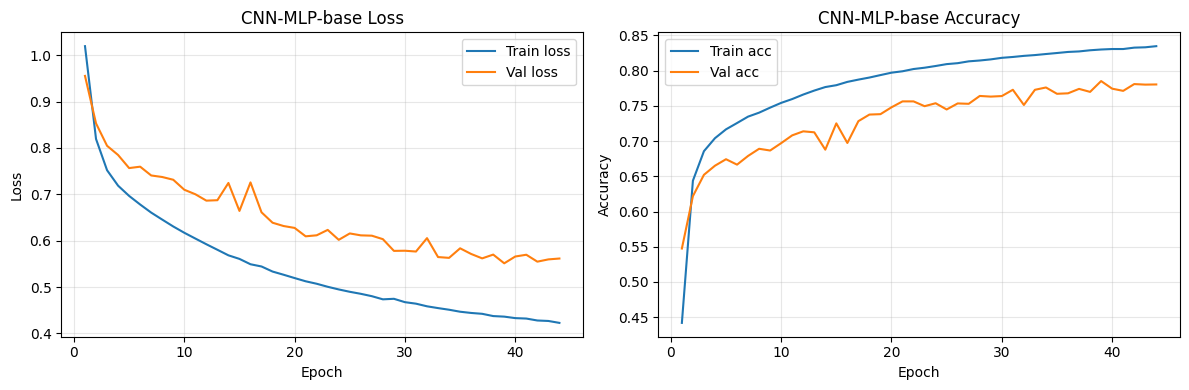

Final train accuracy: 0.835
Final val accuracy:   0.780


In [ ]:
print("\n Training CNN-MLP-base model \n")

set_seed()
train_loader, val_loader = make_loaders(batch_size=64)
model = build_model('CNN-MLP-base', dropout=0.5)

pretune_mlp_base = train_model_tuned(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=100,
    lr=1e-3,
    weight_decay=0.0,
    optimizer_name='adamw',
    patience=5,
    clip_grad=model_settings['CNN-MLP-base']['clip_grad'],
    verbose=True,
    plot_history=True,
    model_name='CNN-MLP-base'
)

print(f"Final train accuracy: {pretune_mlp_base['history'][-1]['train_acc']:.3f}")
print(f"Final val accuracy:   {pretune_mlp_base['history'][-1]['val_acc']:.3f}")



 Training CNN-MLP-sup model 

Epoch 1/100 | train loss: 1.0850 | val loss: 1.1004 | train acc: 0.372 | val acc: 0.354 | val F1: 0.278 | time: 13.34s
Epoch 2/100 | train loss: 0.9867 | val loss: 0.9687 | train acc: 0.463 | val acc: 0.487 | val F1: 0.446 | time: 13.5s
Epoch 3/100 | train loss: 0.9167 | val loss: 0.9458 | train acc: 0.509 | val acc: 0.495 | val F1: 0.432 | time: 13.01s
Epoch 4/100 | train loss: 0.8973 | val loss: 0.9306 | train acc: 0.524 | val acc: 0.503 | val F1: 0.435 | time: 13.32s
Epoch 5/100 | train loss: 0.8820 | val loss: 0.9378 | train acc: 0.547 | val acc: 0.510 | val F1: 0.470 | time: 13.38s
  No improvement for 1 epoch(s)
Epoch 6/100 | train loss: 0.8193 | val loss: 0.8617 | train acc: 0.622 | val acc: 0.618 | val F1: 0.615 | time: 13.39s
Epoch 7/100 | train loss: 0.7240 | val loss: 0.8295 | train acc: 0.699 | val acc: 0.639 | val F1: 0.636 | time: 13.39s
Epoch 8/100 | train loss: 0.6830 | val loss: 0.8000 | train acc: 0.722 | val acc: 0.656 | val F1: 0.654 |

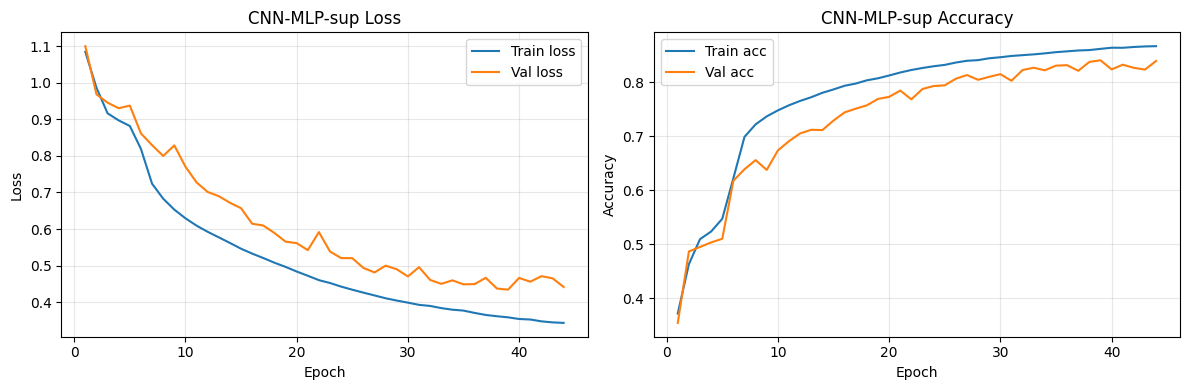

Final train accuracy: 0.867
Final val accuracy:   0.840


In [ ]:
print("\n Training CNN-MLP-sup model \n")

set_seed()
train_loader, val_loader = make_loaders(batch_size=64)
model = build_model('CNN-MLP-sup', dropout=0.5)

pretune_mlp_sup = train_model_tuned(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=100,
    lr=1e-3,
    weight_decay=0.0,
    optimizer_name='adamw',
    patience=5,
    clip_grad=model_settings['CNN-MLP-sup']['clip_grad'],
    verbose=True,
    plot_history=True,
    model_name='CNN-MLP-sup'
)

print(f"Final train accuracy: {pretune_mlp_sup['history'][-1]['train_acc']:.3f}")
print(f"Final val accuracy:   {pretune_mlp_sup['history'][-1]['val_acc']:.3f}")



 Training CNN-LSTM-base model 

Epoch 1/100 | train loss: 1.0453 | val loss: 0.9411 | train acc: 0.436 | val acc: 0.560 | val F1: 0.558 | time: 17.14s
Epoch 2/100 | train loss: 0.7008 | val loss: 0.6936 | train acc: 0.714 | val acc: 0.715 | val F1: 0.714 | time: 17.41s
Epoch 3/100 | train loss: 0.5461 | val loss: 0.5957 | train acc: 0.792 | val acc: 0.773 | val F1: 0.772 | time: 17.61s
Epoch 4/100 | train loss: 0.5002 | val loss: 0.5240 | train acc: 0.813 | val acc: 0.798 | val F1: 0.798 | time: 17.05s
Epoch 5/100 | train loss: 0.4705 | val loss: 0.4993 | train acc: 0.825 | val acc: 0.803 | val F1: 0.803 | time: 17.33s
Epoch 6/100 | train loss: 0.4500 | val loss: 0.4800 | train acc: 0.834 | val acc: 0.818 | val F1: 0.818 | time: 17.06s
Epoch 7/100 | train loss: 0.4349 | val loss: 0.4364 | train acc: 0.840 | val acc: 0.844 | val F1: 0.844 | time: 16.81s
Epoch 8/100 | train loss: 0.4238 | val loss: 0.4187 | train acc: 0.844 | val acc: 0.847 | val F1: 0.848 | time: 17.29s
Epoch 9/100 | t

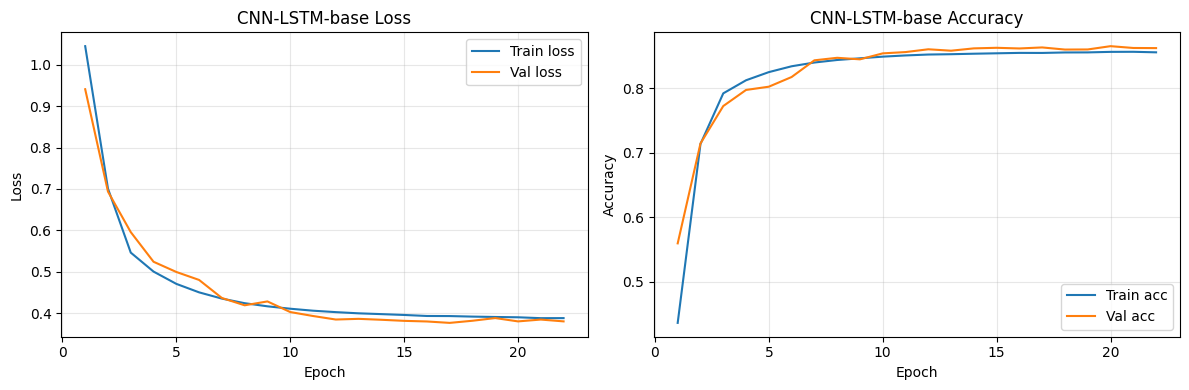

Final train accuracy: 0.856
Final val accuracy:   0.862


In [ ]:
print("\n Training CNN-LSTM-base model \n")

set_seed()
train_loader, val_loader = make_loaders(batch_size=64)
model = build_model('CNN-LSTM-base', dropout=0.3)

pretune_lstm_base = train_model_tuned(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=100,
    lr=1e-3,
    weight_decay=0.0,
    optimizer_name='adamw',
    patience=5,
    clip_grad=model_settings['CNN-LSTM-base']['clip_grad'],
    verbose=True,
    plot_history=True,
    model_name='CNN-LSTM-base'
)

print(f"Final train accuracy: {pretune_lstm_base['history'][-1]['train_acc']:.3f}")
print(f"Final val accuracy:   {pretune_lstm_base['history'][-1]['val_acc']:.3f}")



 Training CNN-LSTM-sup model 

Epoch 1/100 | train loss: 1.0807 | val loss: 0.9976 | train acc: 0.373 | val acc: 0.473 | val F1: 0.392 | time: 17.73s
Epoch 2/100 | train loss: 0.9730 | val loss: 0.9506 | train acc: 0.471 | val acc: 0.501 | val F1: 0.490 | time: 17.49s
Epoch 3/100 | train loss: 0.9415 | val loss: 0.9467 | train acc: 0.494 | val acc: 0.510 | val F1: 0.460 | time: 17.61s
Epoch 4/100 | train loss: 0.9236 | val loss: 0.9324 | train acc: 0.506 | val acc: 0.514 | val F1: 0.503 | time: 17.53s
Epoch 5/100 | train loss: 0.9124 | val loss: 0.9342 | train acc: 0.520 | val acc: 0.514 | val F1: 0.490 | time: 17.53s
  No improvement for 1 epoch(s)
Epoch 6/100 | train loss: 0.8825 | val loss: 0.9338 | train acc: 0.568 | val acc: 0.536 | val F1: 0.520 | time: 17.41s
  No improvement for 2 epoch(s)
Epoch 7/100 | train loss: 0.8206 | val loss: 0.8762 | train acc: 0.631 | val acc: 0.602 | val F1: 0.599 | time: 17.42s
Epoch 8/100 | train loss: 0.7528 | val loss: 0.7852 | train acc: 0.680 

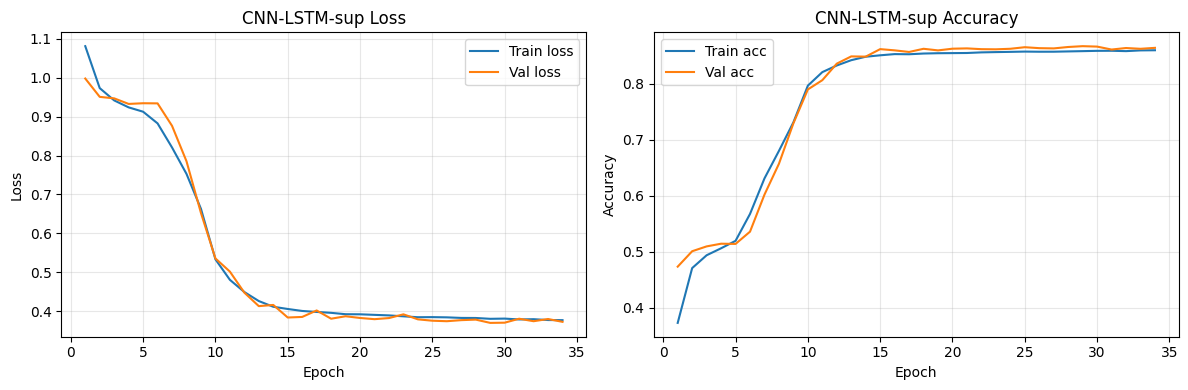

Final train accuracy: 0.860
Final val accuracy:   0.864


In [ ]:
print("\n Training CNN-LSTM-sup model \n")

set_seed()
train_loader, val_loader = make_loaders(batch_size=64)
model = build_model('CNN-LSTM-sup', dropout=0.3)

pretune_lstm_sup = train_model_tuned(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=100,
    lr=1e-3,
    weight_decay=0.0,
    optimizer_name='adamw',
    patience=5,
    clip_grad=model_settings['CNN-LSTM-sup']['clip_grad'],
    verbose=True,
    plot_history=True,
    model_name='CNN-LSTM-sup'
)

print(f"Final train accuracy: {pretune_lstm_sup['history'][-1]['train_acc']:.3f}")
print(f"Final val accuracy:   {pretune_lstm_sup['history'][-1]['val_acc']:.3f}")


### Save pretuning weights


In [ ]:
"""Persist pretuning weights to Drive so any later cell can reload the trained models without retraining."""
os.makedirs(f'{SAVE_DIR}/weights', exist_ok=True)

pretune_results = {
    'CNN-MLP-base':  pretune_mlp_base,
    'CNN-MLP-sup':   pretune_mlp_sup,
    'CNN-LSTM-base': pretune_lstm_base,
    'CNN-LSTM-sup':  pretune_lstm_sup,
}

for name, result in pretune_results.items():
    path = f"{SAVE_DIR}/weights/pretune_{name}.pt"
    torch.save({
        'model_state_dict': result['model'].state_dict(),
        'best_val_loss':    result['best_val_loss'],
        'best_val_f1':      result['best_val_f1'],
        'best_val_acc':     result['best_val_acc'],
        'best_epoch':       result['best_epoch'],
        'epochs_run':       result['epochs_run'],
    }, path)
    print(f"Saved {name:>14s} → {path}")


Saved   CNN-MLP-base → /content/drive/MyDrive/st311/tuning/weights/pretune_CNN-MLP-base.pt
Saved    CNN-MLP-sup → /content/drive/MyDrive/st311/tuning/weights/pretune_CNN-MLP-sup.pt
Saved  CNN-LSTM-base → /content/drive/MyDrive/st311/tuning/weights/pretune_CNN-LSTM-base.pt
Saved   CNN-LSTM-sup → /content/drive/MyDrive/st311/tuning/weights/pretune_CNN-LSTM-sup.pt


## Hyperparameter tuning

Tuning runs in two stages on the chronological validation split. Stage 1 grid searches learning rate against batch size with dropout fixed at 0.3 and weight decay at zero. Stage 2 fixes the best learning rate and batch size for each architecture and grid searches dropout against weight decay. Each trial is ranked by best validation weighted F1 with best validation loss as a tiebreaker.


In [19]:
def stage1_tune_lr_batch(model_name,
                         lr_grid=[5e-4, 1e-3, 2e-3],
                         batch_grid=[32, 64, 128],
                         seed=42, tune_epochs=20, patience=3):
    """Grid search over learning rate and batch size for one architecture.

    Sweeps every (lr, batch_size) pair in the supplied grids. For each trial the seed
    is reset so the weight initialisation and shuffle order are identical across
    candidates, isolating the contribution of the swept hyperparameters. After every
    trial a partial CSV is written to Drive so progress is observable mid run.

    Returns a DataFrame sorted with the best trial first by val F1 with val loss tiebreak.
    """
    rows = []
    n_trials = len(lr_grid) * len(batch_grid)
    trial = 0

    for lr in lr_grid:
        for batch_size in batch_grid:
            trial += 1
            print(f"\n[{model_name}] Stage 1 trial {trial}/{n_trials}: "
                  f"lr={lr:.6f}, batch_size={batch_size}")

            set_seed(seed)
            train_loader, val_loader = make_loaders(batch_size=batch_size, seed=seed)
            model = build_model(model_name, dropout=0.3)

            result = train_model_tuned(
                model=model,
                train_loader=train_loader,
                val_loader=val_loader,
                num_epochs=tune_epochs,
                lr=lr,
                weight_decay=0.0,
                optimizer_name='adamw',
                patience=patience,
                clip_grad=model_settings[model_name]['clip_grad'],
                verbose=False,
                plot_history=False,
                model_name=model_name
            )

            rows.append({
                'model': model_name,
                'stage': 'lr_batch',
                'trial': trial,
                'lr': lr,
                'batch_size': batch_size,
                'dropout': 0.3,
                'weight_decay': 0.0,
                'best_epoch': result['best_epoch'],
                'epochs_run': result['epochs_run'],
                'val_loss': result['best_val_loss'],
                'val_acc': result['best_val_acc'],
                'val_f1': result['best_val_f1'],
            })

            print(f"  val_loss={result['best_val_loss']:.4f}, "
                  f"val_f1={result['best_val_f1']:.4f}")

            pd.DataFrame(rows).to_csv(f"{SAVE_DIR}/stage1_{model_name}_partial.csv", index=False)

    df = pd.DataFrame(rows)
    df = df.sort_values(['val_f1', 'val_loss'], ascending=[False, True]).reset_index(drop=True)

    print(f"\nBest Stage 1 config for {model_name}:")
    print(df.head(1).to_string(index=False))

    return df


### Stage 1: CNN MLP


In [20]:
# Reload from Drive if a previous session already produced results, otherwise run the search.
csv_path = f"{SAVE_DIR}/stage1_CNN-MLP-base.csv"
if os.path.exists(csv_path):
    print(f"Loading existing Stage 1 results from {csv_path}")
    stage1_cnn_mlp_base = pd.read_csv(csv_path)
else:
    stage1_cnn_mlp_base = stage1_tune_lr_batch(
        model_name='CNN-MLP-base',
        seed=42,
        tune_epochs=20,
        patience=3
    )
    stage1_cnn_mlp_base.to_csv(csv_path, index=False)
    print(f"Saved Stage 1 results to {csv_path}")

stage1_cnn_mlp_base.head()


Loading existing Stage 1 results from /content/drive/MyDrive/st311/tuning/stage1_CNN-MLP-base.csv


,model,stage,trial,lr,batch_size,dropout,weight_decay,best_epoch,epochs_run,val_loss,val_acc,val_f1
0,CNN-MLP-base,lr_batch,4,0.0010,32,0.3,0.0,20,20,0.570343,0.774377,0.774572
1,CNN-MLP-base,lr_batch,8,0.0020,64,0.3,0.0,18,20,0.595938,0.771039,0.771103
2,CNN-MLP-base,lr_batch,5,0.0010,64,0.3,0.0,18,20,0.596598,0.763204,0.762781
3,CNN-MLP-base,lr_batch,9,0.0020,128,0.3,0.0,20,20,0.619656,0.749833,0.748947
4,CNN-MLP-base,lr_batch,1,0.0005,32,0.3,0.0,19,20,0.632216,0.736069,0.736122


In [21]:
# Reload from Drive if a previous session already produced results, otherwise run the search.
csv_path = f"{SAVE_DIR}/stage1_CNN-MLP-sup.csv"
if os.path.exists(csv_path):
    print(f"Loading existing Stage 1 results from {csv_path}")
    stage1_cnn_mlp_sup = pd.read_csv(csv_path)
else:
    stage1_cnn_mlp_sup = stage1_tune_lr_batch(
        model_name='CNN-MLP-sup',
        seed=42,
        tune_epochs=20,
        patience=3
    )
    stage1_cnn_mlp_sup.to_csv(csv_path, index=False)
    print(f"Saved Stage 1 results to {csv_path}")

stage1_cnn_mlp_sup.head()


Loading existing Stage 1 results from /content/drive/MyDrive/st311/tuning/stage1_CNN-MLP-sup.csv


,model,stage,trial,lr,batch_size,dropout,weight_decay,best_epoch,epochs_run,val_loss,val_acc,val_f1
0,CNN-MLP-sup,lr_batch,4,0.0010,32,0.3,0.0,20,20,0.440193,0.832633,0.832961
1,CNN-MLP-sup,lr_batch,1,0.0005,32,0.3,0.0,20,20,0.496928,0.806813,0.806523
2,CNN-MLP-sup,lr_batch,5,0.0010,64,0.3,0.0,17,20,0.551663,0.786511,0.786231
3,CNN-MLP-sup,lr_batch,6,0.0010,128,0.3,0.0,19,20,0.554951,0.778205,0.776872
4,CNN-MLP-sup,lr_batch,8,0.0020,64,0.3,0.0,20,20,0.597353,0.757589,0.757097


### Stage 1: CNN LSTM


In [22]:
# Reload from Drive if a previous session already produced results, otherwise run the search.
csv_path = f"{SAVE_DIR}/stage1_CNN-LSTM-base.csv"
if os.path.exists(csv_path):
    print(f"Loading existing Stage 1 results from {csv_path}")
    stage1_cnn_lstm_base = pd.read_csv(csv_path)
else:
    stage1_cnn_lstm_base = stage1_tune_lr_batch(
        model_name='CNN-LSTM-base',
        seed=42,
        tune_epochs=20,
        patience=3
    )
    stage1_cnn_lstm_base.to_csv(csv_path, index=False)
    print(f"Saved Stage 1 results to {csv_path}")

stage1_cnn_lstm_base.head()


Loading existing Stage 1 results from /content/drive/MyDrive/st311/tuning/stage1_CNN-LSTM-base.csv


,model,stage,trial,lr,batch_size,dropout,weight_decay,best_epoch,epochs_run,val_loss,val_acc,val_f1
0,CNN-LSTM-base,lr_batch,6,0.001,128,0.3,0.0,19,20,0.373113,0.866601,0.866825
1,CNN-LSTM-base,lr_batch,8,0.002,64,0.3,0.0,18,20,0.369636,0.865502,0.866030
2,CNN-LSTM-base,lr_batch,4,0.001,32,0.3,0.0,11,14,0.378043,0.864795,0.864999
3,CNN-LSTM-base,lr_batch,5,0.001,64,0.3,0.0,17,20,0.373490,0.864795,0.864986
4,CNN-LSTM-base,lr_batch,9,0.002,128,0.3,0.0,18,20,0.372375,0.864343,0.864652


In [23]:
# Reload from Drive if a previous session already produced results, otherwise run the search.
csv_path = f"{SAVE_DIR}/stage1_CNN-LSTM-sup.csv"
if os.path.exists(csv_path):
    print(f"Loading existing Stage 1 results from {csv_path}")
    stage1_cnn_lstm_sup = pd.read_csv(csv_path)
else:
    stage1_cnn_lstm_sup = stage1_tune_lr_batch(
        model_name='CNN-LSTM-sup',
        seed=42,
        tune_epochs=20,
        patience=3
    )
    stage1_cnn_lstm_sup.to_csv(csv_path, index=False)
    print(f"Saved Stage 1 results to {csv_path}")

stage1_cnn_lstm_sup.head()


Loading existing Stage 1 results from /content/drive/MyDrive/st311/tuning/stage1_CNN-LSTM-sup.csv


,model,stage,trial,lr,batch_size,dropout,weight_decay,best_epoch,epochs_run,val_loss,val_acc,val_f1
0,CNN-LSTM-sup,lr_batch,8,0.0020,64,0.3,0.0,11,14,0.370047,0.867661,0.867937
1,CNN-LSTM-sup,lr_batch,2,0.0005,64,0.3,0.0,20,20,0.374178,0.865718,0.865954
2,CNN-LSTM-sup,lr_batch,4,0.0010,32,0.3,0.0,16,19,0.367831,0.865345,0.865648
3,CNN-LSTM-sup,lr_batch,7,0.0020,32,0.3,0.0,7,10,0.380296,0.864932,0.865222
4,CNN-LSTM-sup,lr_batch,5,0.0010,64,0.3,0.0,18,20,0.370712,0.864598,0.865064


Combine the four per architecture Stage 1 DataFrames so Stage 2 reads each architecture's winner from one place.


In [24]:
stage1_df = pd.concat(
    [stage1_cnn_mlp_base, stage1_cnn_mlp_sup, stage1_cnn_lstm_base, stage1_cnn_lstm_sup],
    ignore_index=True
)
stage1_df.to_csv(f"{SAVE_DIR}/stage1_lr_batch_results.csv", index=False)

stage1_df.sort_values(['model', 'val_f1'], ascending=[True, False]).head(10)


,model,stage,trial,lr,batch_size,dropout,weight_decay,best_epoch,epochs_run,val_loss,val_acc,val_f1
18,CNN-LSTM-base,lr_batch,6,0.0010,128,0.3,0.0,19,20,0.373113,0.866601,0.866825
19,CNN-LSTM-base,lr_batch,8,0.0020,64,0.3,0.0,18,20,0.369636,0.865502,0.866030
20,CNN-LSTM-base,lr_batch,4,0.0010,32,0.3,0.0,11,14,0.378043,0.864795,0.864999
21,CNN-LSTM-base,lr_batch,5,0.0010,64,0.3,0.0,17,20,0.373490,0.864795,0.864986
22,CNN-LSTM-base,lr_batch,9,0.0020,128,0.3,0.0,18,20,0.372375,0.864343,0.864652
23,CNN-LSTM-base,lr_batch,7,0.0020,32,0.3,0.0,10,13,0.380500,0.863440,0.863611
24,CNN-LSTM-base,lr_batch,1,0.0005,32,0.3,0.0,20,20,0.386138,0.858198,0.858522
25,CNN-LSTM-base,lr_batch,3,0.0005,128,0.3,0.0,20,20,0.417542,0.849067,0.849233
26,CNN-LSTM-base,lr_batch,2,0.0005,64,0.3,0.0,18,20,0.409321,0.848105,0.848646
27,CNN-LSTM-sup,lr_batch,8,0.0020,64,0.3,0.0,11,14,0.370047,0.867661,0.867937


In [25]:
def stage2_tune_dropout_wd(model_name, stage1_df,
                           dropout_grid=[0.0, 0.1, 0.2, 0.3, 0.5],
                           wd_grid=[0.0, 1e-5, 1e-4, 5e-4, 1e-3],
                           seed=42, tune_epochs=12, patience=3):
    """Grid search dropout against weight decay using the Stage 1 winner for lr and batch size.

    The conditioning point comes from stage1_df by filtering for this model name and
    taking the top row under the same val F1 with val loss tiebreak rule. Each
    (dropout, weight_decay) pair is then trained at those fixed lr and batch settings.
    Partial CSVs are written after every trial so progress is observable mid run.

    Returns a DataFrame sorted with the best trial first.
    """
    best_stage1 = (
        stage1_df[stage1_df['model'] == model_name]
        .sort_values(['val_f1', 'val_loss'], ascending=[False, True])
        .iloc[0]
    )

    best_lr = float(best_stage1['lr'])
    best_batch = int(best_stage1['batch_size'])

    print(f"\n[{model_name}] Stage 2 using fixed lr={best_lr:.6f}, "
          f"batch_size={best_batch}")

    rows = []

    for dropout in dropout_grid:
        for wd in wd_grid:
            print(f"\n[{model_name}] Stage 2: dropout={dropout}, weight_decay={wd}")

            set_seed(seed)
            train_loader, val_loader = make_loaders(batch_size=best_batch, seed=seed)
            model = build_model(model_name, dropout=dropout)

            result = train_model_tuned(
                model=model,
                train_loader=train_loader,
                val_loader=val_loader,
                num_epochs=tune_epochs,
                lr=best_lr,
                weight_decay=wd,
                optimizer_name='adamw',
                patience=patience,
                clip_grad=model_settings[model_name]['clip_grad'],
                verbose=False,
                plot_history=False,
                model_name=model_name
            )

            rows.append({
                'model': model_name,
                'stage': 'dropout_wd',
                'lr': best_lr,
                'batch_size': best_batch,
                'dropout': dropout,
                'weight_decay': wd,
                'best_epoch': result['best_epoch'],
                'epochs_run': result['epochs_run'],
                'val_loss': result['best_val_loss'],
                'val_acc': result['best_val_acc'],
                'val_f1': result['best_val_f1'],
            })

            print(f"  val_loss={result['best_val_loss']:.4f}, "
                  f"val_f1={result['best_val_f1']:.4f}")

            pd.DataFrame(rows).to_csv(f"{SAVE_DIR}/stage2_{model_name}_partial.csv", index=False)

    df = pd.DataFrame(rows)
    df = df.sort_values(['val_f1', 'val_loss'], ascending=[False, True]).reset_index(drop=True)

    print(f"\nBest Stage 2 config for {model_name}:")
    print(df.head(1).to_string(index=False))

    return df


### Stage 2: CNN MLP


In [26]:
# Reload from Drive if a previous session already produced results, otherwise run the grid search.
csv_path = f"{SAVE_DIR}/stage2_CNN-MLP-base.csv"
if os.path.exists(csv_path):
    print(f"Loading existing Stage 2 results from {csv_path}")
    stage2_cnn_mlp_base = pd.read_csv(csv_path)
else:
    stage2_cnn_mlp_base = stage2_tune_dropout_wd(
        model_name='CNN-MLP-base',
        stage1_df=stage1_df,
        dropout_grid=[0.1, 0.3, 0.5],
        wd_grid=[0.0, 1e-4, 1e-3],
        seed=42,
        tune_epochs=25,
        patience=3
    )
    stage2_cnn_mlp_base.to_csv(csv_path, index=False)
    print(f"Saved Stage 2 results to {csv_path}")

stage2_cnn_mlp_base.head()


Loading existing Stage 2 results from /content/drive/MyDrive/st311/tuning/stage2_CNN-MLP-base.csv


,model,stage,lr,batch_size,dropout,weight_decay,best_epoch,epochs_run,val_loss,val_acc,val_f1
0,CNN-MLP-base,dropout_wd,0.001,32,0.5,0.0010,25,25,0.526302,0.792500,0.792803
1,CNN-MLP-base,dropout_wd,0.001,32,0.3,0.0010,20,23,0.570173,0.775908,0.775897
2,CNN-MLP-base,dropout_wd,0.001,32,0.3,0.0000,21,24,0.563658,0.775633,0.775327
3,CNN-MLP-base,dropout_wd,0.001,32,0.5,0.0000,24,25,0.582837,0.770921,0.769932
4,CNN-MLP-base,dropout_wd,0.001,32,0.1,0.0001,16,19,0.586594,0.763852,0.764450


In [27]:
# Reload from Drive if a previous session already produced results, otherwise run the grid search.
csv_path = f"{SAVE_DIR}/stage2_CNN-MLP-sup.csv"
if os.path.exists(csv_path):
    print(f"Loading existing Stage 2 results from {csv_path}")
    stage2_cnn_mlp_sup = pd.read_csv(csv_path)
else:
    stage2_cnn_mlp_sup = stage2_tune_dropout_wd(
        model_name='CNN-MLP-sup',
        stage1_df=stage1_df,
        dropout_grid=[0.1, 0.3, 0.5],
        wd_grid=[0.0, 1e-4, 1e-3],
        seed=42,
        tune_epochs=25,
        patience=3
    )
    stage2_cnn_mlp_sup.to_csv(csv_path, index=False)
    print(f"Saved Stage 2 results to {csv_path}")

stage2_cnn_mlp_sup.head()


Loading existing Stage 2 results from /content/drive/MyDrive/st311/tuning/stage2_CNN-MLP-sup.csv


,model,stage,lr,batch_size,dropout,weight_decay,best_epoch,epochs_run,val_loss,val_acc,val_f1
0,CNN-MLP-sup,dropout_wd,0.001,32,0.3,0.0000,22,25,0.417558,0.847300,0.847496
1,CNN-MLP-sup,dropout_wd,0.001,32,0.1,0.0000,18,21,0.441382,0.837601,0.837806
2,CNN-MLP-sup,dropout_wd,0.001,32,0.5,0.0000,24,25,0.433659,0.835421,0.836110
3,CNN-MLP-sup,dropout_wd,0.001,32,0.3,0.0001,17,20,0.451832,0.833831,0.833838
4,CNN-MLP-sup,dropout_wd,0.001,32,0.1,0.0001,18,21,0.453881,0.828667,0.829340


### Stage 2: CNN LSTM


In [28]:
# Reload from Drive if a previous session already produced results, otherwise run the grid search.
csv_path = f"{SAVE_DIR}/stage2_CNN-LSTM-base.csv"
if os.path.exists(csv_path):
    print(f"Loading existing Stage 2 results from {csv_path}")
    stage2_cnn_lstm_base = pd.read_csv(csv_path)
else:
    stage2_cnn_lstm_base = stage2_tune_dropout_wd(
        model_name='CNN-LSTM-base',
        stage1_df=stage1_df,
        dropout_grid=[0.0, 0.1, 0.3, 0.5],
        wd_grid=[0.0, 1e-4, 1e-3],
        seed=42,
        tune_epochs=25,
        patience=3
    )
    stage2_cnn_lstm_base.to_csv(csv_path, index=False)
    print(f"Saved Stage 2 results to {csv_path}")

stage2_cnn_lstm_base.head()


Loading existing Stage 2 results from /content/drive/MyDrive/st311/tuning/stage2_CNN-LSTM-base.csv


,model,stage,lr,batch_size,dropout,weight_decay,best_epoch,epochs_run,val_loss,val_acc,val_f1
0,CNN-LSTM-base,dropout_wd,0.001,128,0.0,0.0010,24,25,0.366103,0.867779,0.868042
1,CNN-LSTM-base,dropout_wd,0.001,128,0.0,0.0001,22,25,0.371789,0.865855,0.865985
2,CNN-LSTM-base,dropout_wd,0.001,128,0.0,0.0000,16,19,0.374153,0.865188,0.865355
3,CNN-LSTM-base,dropout_wd,0.001,128,0.3,0.0000,22,25,0.372341,0.865070,0.865293
4,CNN-LSTM-base,dropout_wd,0.001,128,0.1,0.0000,22,25,0.377117,0.864167,0.864305


In [29]:
# Reload from Drive if a previous session already produced results, otherwise run the grid search.
csv_path = f"{SAVE_DIR}/stage2_CNN-LSTM-sup.csv"
if os.path.exists(csv_path):
    print(f"Loading existing Stage 2 results from {csv_path}")
    stage2_cnn_lstm_sup = pd.read_csv(csv_path)
else:
    stage2_cnn_lstm_sup = stage2_tune_dropout_wd(
        model_name='CNN-LSTM-sup',
        stage1_df=stage1_df,
        dropout_grid=[0.0, 0.1, 0.3, 0.5],
        wd_grid=[0.0, 1e-4, 1e-3],
        seed=42,
        tune_epochs=25,
        patience=3
    )
    stage2_cnn_lstm_sup.to_csv(csv_path, index=False)
    print(f"Saved Stage 2 results to {csv_path}")

stage2_cnn_lstm_sup.head()


Loading existing Stage 2 results from /content/drive/MyDrive/st311/tuning/stage2_CNN-LSTM-sup.csv


,model,stage,lr,batch_size,dropout,weight_decay,best_epoch,epochs_run,val_loss,val_acc,val_f1
0,CNN-LSTM-sup,dropout_wd,0.002,64,0.0,0.0001,7,10,0.370357,0.867347,0.867668
1,CNN-LSTM-sup,dropout_wd,0.002,64,0.0,0.0000,16,19,0.366560,0.867033,0.867251
2,CNN-LSTM-sup,dropout_wd,0.002,64,0.3,0.0010,13,16,0.371977,0.866071,0.866251
3,CNN-LSTM-sup,dropout_wd,0.002,64,0.1,0.0001,8,11,0.370471,0.866012,0.866236
4,CNN-LSTM-sup,dropout_wd,0.002,64,0.5,0.0001,13,16,0.374519,0.865659,0.865982


Combine the four per architecture Stage 2 grids so the final training step reads each architecture's winner from one place.


In [30]:
stage2_df = pd.concat(
    [stage2_cnn_mlp_base, stage2_cnn_mlp_sup, stage2_cnn_lstm_base, stage2_cnn_lstm_sup],
    ignore_index=True
)
stage2_df.to_csv(f"{SAVE_DIR}/stage2_dropout_wd_results.csv", index=False)

stage2_df.sort_values(['model', 'val_f1'], ascending=[True, False]).head(10)


,model,stage,lr,batch_size,dropout,weight_decay,best_epoch,epochs_run,val_loss,val_acc,val_f1
18,CNN-LSTM-base,dropout_wd,0.001,128,0.0,0.0010,24,25,0.366103,0.867779,0.868042
19,CNN-LSTM-base,dropout_wd,0.001,128,0.0,0.0001,22,25,0.371789,0.865855,0.865985
20,CNN-LSTM-base,dropout_wd,0.001,128,0.0,0.0000,16,19,0.374153,0.865188,0.865355
21,CNN-LSTM-base,dropout_wd,0.001,128,0.3,0.0000,22,25,0.372341,0.865070,0.865293
22,CNN-LSTM-base,dropout_wd,0.001,128,0.1,0.0000,22,25,0.377117,0.864167,0.864305
23,CNN-LSTM-base,dropout_wd,0.001,128,0.1,0.0001,17,20,0.374281,0.863342,0.863506
24,CNN-LSTM-base,dropout_wd,0.001,128,0.3,0.0010,23,25,0.374477,0.862949,0.863126
25,CNN-LSTM-base,dropout_wd,0.001,128,0.5,0.0010,25,25,0.382169,0.862655,0.863038
26,CNN-LSTM-base,dropout_wd,0.001,128,0.3,0.0001,22,25,0.377039,0.862301,0.862566
27,CNN-LSTM-base,dropout_wd,0.001,128,0.1,0.0010,22,25,0.378498,0.862223,0.862434


## Final training with selected hyperparameters

Each architecture is retrained from scratch on its Stage 2 winner. The held out test set remains untouched until the final evaluation section.


In [31]:
def train_final_model(model_name, stage2_df, final_epochs=30, seed=42):
    """Retrain one architecture from scratch using its Stage 2 winning configuration.

    Filters stage2_df by model name, picks the row with the best val F1 with val loss
    tiebreak, and trains for up to final_epochs at those exact lr, batch size, dropout,
    and weight decay. Returns the trained model, the full result dict, and the row of
    selected configuration values for the summary table downstream.
    """
    best = (
        stage2_df[stage2_df['model'] == model_name]
        .sort_values(['val_f1', 'val_loss'], ascending=[False, True])
        .iloc[0]
    )

    lr = float(best['lr'])
    batch_size = int(best['batch_size'])
    dropout = float(best['dropout'])
    weight_decay = float(best['weight_decay'])

    print(f"\nFinal training {model_name}")
    print(f"lr={lr:.6f}, batch_size={batch_size}, "
          f"dropout={dropout}, weight_decay={weight_decay}")

    set_seed(seed)
    train_loader, val_loader = make_loaders(batch_size=batch_size, seed=seed)
    model = build_model(model_name, dropout=dropout)

    result = train_model_tuned(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=final_epochs,
        lr=lr,
        weight_decay=weight_decay,
        optimizer_name='adamw',
        patience=7,
        clip_grad=model_settings[model_name]['clip_grad'],
        verbose=True,
        plot_history=True,
        model_name=model_name
    )

    return result['model'], result, best


### Final training: CNN MLP base



Final training CNN-MLP-base
lr=0.001000, batch_size=32, dropout=0.5, weight_decay=0.001
Epoch 1/100 | train loss: 1.0495 | val loss: 1.0018 | train acc: 0.415 | val acc: 0.518 | val F1: 0.518 | time: 25.54s
Epoch 2/100 | train loss: 0.8682 | val loss: 0.8703 | train acc: 0.602 | val acc: 0.618 | val F1: 0.619 | time: 24.54s
Epoch 3/100 | train loss: 0.7710 | val loss: 0.8067 | train acc: 0.677 | val acc: 0.655 | val F1: 0.655 | time: 24.19s
Epoch 4/100 | train loss: 0.7258 | val loss: 0.7855 | train acc: 0.703 | val acc: 0.670 | val F1: 0.670 | time: 24.65s
Epoch 5/100 | train loss: 0.6970 | val loss: 0.7560 | train acc: 0.719 | val acc: 0.685 | val F1: 0.684 | time: 23.98s
Epoch 6/100 | train loss: 0.6720 | val loss: 0.7577 | train acc: 0.731 | val acc: 0.670 | val F1: 0.668 | time: 24.5s
  No improvement for 1 epoch(s)
Epoch 7/100 | train loss: 0.6464 | val loss: 0.7161 | train acc: 0.744 | val acc: 0.698 | val F1: 0.698 | time: 24.18s
Epoch 8/100 | train loss: 0.6301 | val loss: 0.

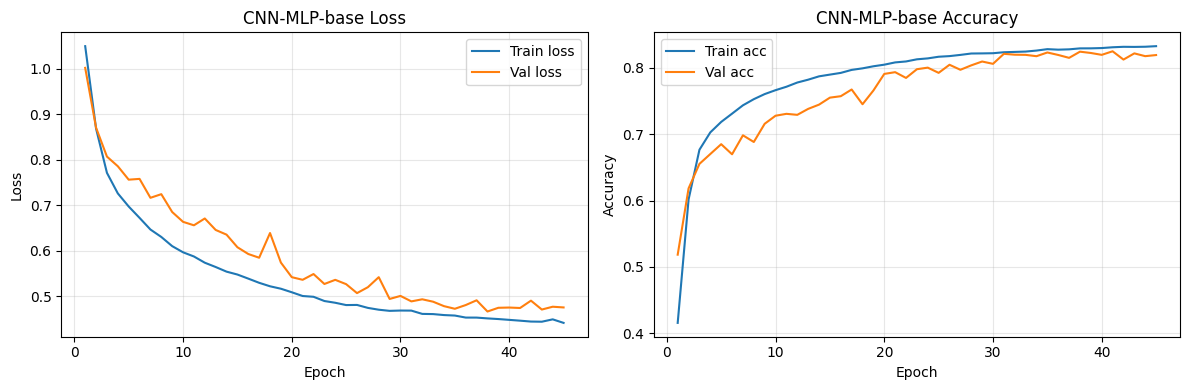

In [32]:
model_mlp_base, results_mlp_base, best_mlp_base_cfg = train_final_model('CNN-MLP-base', stage2_df, final_epochs=100)


### Final training: CNN MLP sup



Final training CNN-MLP-sup
lr=0.001000, batch_size=32, dropout=0.3, weight_decay=0.0
Epoch 1/100 | train loss: 1.0442 | val loss: 1.0111 | train acc: 0.410 | val acc: 0.470 | val F1: 0.426 | time: 25.38s
Epoch 2/100 | train loss: 0.9207 | val loss: 0.9750 | train acc: 0.511 | val acc: 0.494 | val F1: 0.491 | time: 24.87s
Epoch 3/100 | train loss: 0.8955 | val loss: 0.9548 | train acc: 0.543 | val acc: 0.528 | val F1: 0.505 | time: 25.35s
Epoch 4/100 | train loss: 0.7701 | val loss: 0.8274 | train acc: 0.672 | val acc: 0.638 | val F1: 0.638 | time: 24.73s
Epoch 5/100 | train loss: 0.7028 | val loss: 0.8037 | train acc: 0.712 | val acc: 0.655 | val F1: 0.655 | time: 24.56s
Epoch 6/100 | train loss: 0.6658 | val loss: 0.8449 | train acc: 0.731 | val acc: 0.624 | val F1: 0.620 | time: 25.55s
  No improvement for 1 epoch(s)
Epoch 7/100 | train loss: 0.6325 | val loss: 0.7235 | train acc: 0.747 | val acc: 0.697 | val F1: 0.697 | time: 24.79s
Epoch 8/100 | train loss: 0.5986 | val loss: 0.67

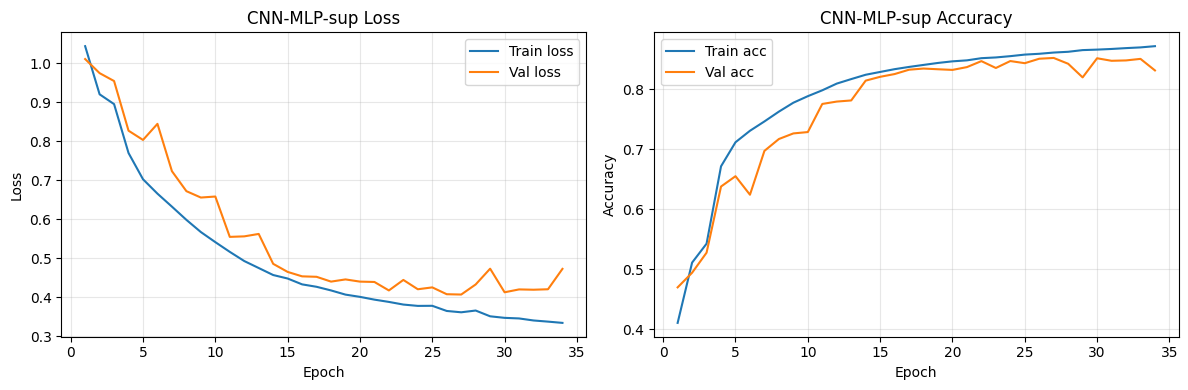

In [33]:
model_mlp_sup, results_mlp_sup, best_mlp_sup_cfg = train_final_model('CNN-MLP-sup', stage2_df, final_epochs=100)


### Final training: CNN LSTM base



Final training CNN-LSTM-base
lr=0.001000, batch_size=128, dropout=0.0, weight_decay=0.001
Epoch 1/100 | train loss: 1.0786 | val loss: 1.0731 | train acc: 0.388 | val acc: 0.449 | val F1: 0.397 | time: 10.62s
Epoch 2/100 | train loss: 0.9254 | val loss: 0.8218 | train acc: 0.568 | val acc: 0.658 | val F1: 0.655 | time: 9.58s
Epoch 3/100 | train loss: 0.6315 | val loss: 0.6950 | train acc: 0.749 | val acc: 0.710 | val F1: 0.710 | time: 9.52s
Epoch 4/100 | train loss: 0.5433 | val loss: 0.6353 | train acc: 0.790 | val acc: 0.747 | val F1: 0.747 | time: 9.74s
Epoch 5/100 | train loss: 0.5030 | val loss: 0.5544 | train acc: 0.808 | val acc: 0.785 | val F1: 0.785 | time: 9.61s
Epoch 6/100 | train loss: 0.4722 | val loss: 0.5128 | train acc: 0.821 | val acc: 0.803 | val F1: 0.804 | time: 9.3s
Epoch 7/100 | train loss: 0.4466 | val loss: 0.4665 | train acc: 0.831 | val acc: 0.826 | val F1: 0.826 | time: 10.49s
Epoch 8/100 | train loss: 0.4287 | val loss: 0.4516 | train acc: 0.839 | val acc: 

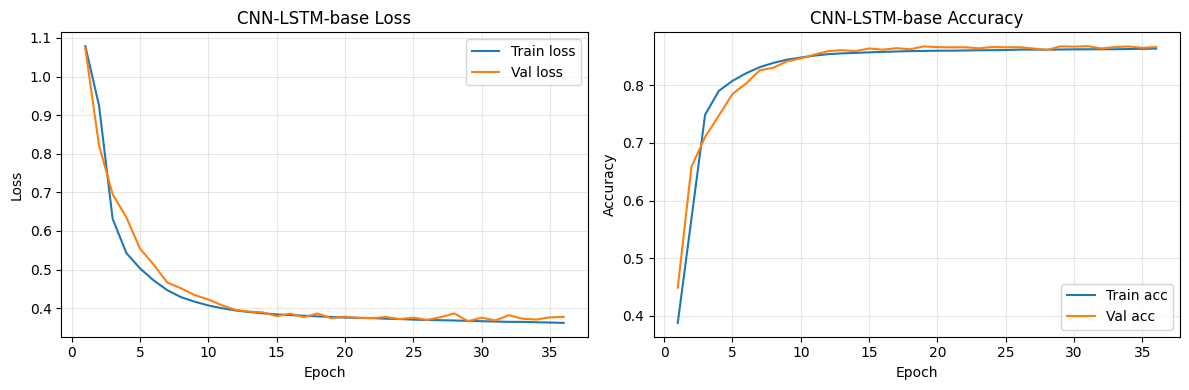

In [34]:
model_lstm_base, results_lstm_base, best_lstm_base_cfg = train_final_model('CNN-LSTM-base', stage2_df, final_epochs=100)


### Final training: CNN LSTM sup



Final training CNN-LSTM-sup
lr=0.002000, batch_size=64, dropout=0.0, weight_decay=0.0001
Epoch 1/100 | train loss: 1.0931 | val loss: 1.0851 | train acc: 0.356 | val acc: 0.398 | val F1: 0.278 | time: 18.57s
Epoch 2/100 | train loss: 0.8847 | val loss: 0.8132 | train acc: 0.587 | val acc: 0.648 | val F1: 0.647 | time: 17.12s
Epoch 3/100 | train loss: 0.5666 | val loss: 0.5263 | train acc: 0.779 | val acc: 0.807 | val F1: 0.807 | time: 17.74s
Epoch 4/100 | train loss: 0.4387 | val loss: 0.4208 | train acc: 0.837 | val acc: 0.845 | val F1: 0.846 | time: 17.66s
Epoch 5/100 | train loss: 0.4042 | val loss: 0.4009 | train acc: 0.850 | val acc: 0.852 | val F1: 0.853 | time: 17.55s
Epoch 6/100 | train loss: 0.3949 | val loss: 0.3844 | train acc: 0.854 | val acc: 0.861 | val F1: 0.861 | time: 16.98s
Epoch 7/100 | train loss: 0.3900 | val loss: 0.3726 | train acc: 0.855 | val acc: 0.865 | val F1: 0.865 | time: 17.36s
Epoch 8/100 | train loss: 0.3874 | val loss: 0.3826 | train acc: 0.856 | val 

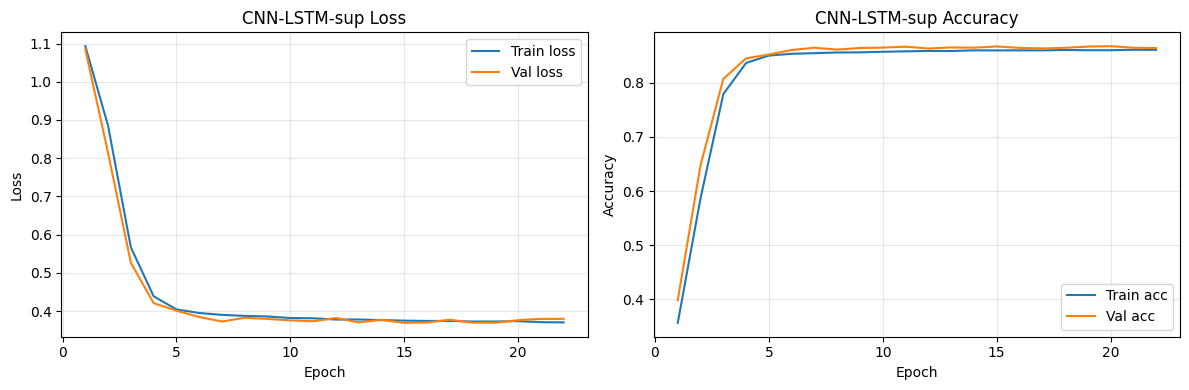

In [35]:
model_lstm_sup, results_lstm_sup, best_lstm_sup_cfg = train_final_model('CNN-LSTM-sup', stage2_df, final_epochs=100)


### Save final training weights


In [36]:
"""Persist final training weights and selected configurations to Drive.

Each saved checkpoint stores the state_dict together with the metrics from the best
epoch and the four hyperparameters chosen by the two stage search. Loading back a
checkpoint and feeding the dropout value into build_model is enough to recover an
identically configured model that can immediately consume the held out test data.
"""
os.makedirs(f'{SAVE_DIR}/weights', exist_ok=True)

final_models = {
    'CNN-MLP-base':  (model_mlp_base,  results_mlp_base,  best_mlp_base_cfg),
    'CNN-MLP-sup':   (model_mlp_sup,   results_mlp_sup,   best_mlp_sup_cfg),
    'CNN-LSTM-base': (model_lstm_base, results_lstm_base, best_lstm_base_cfg),
    'CNN-LSTM-sup':  (model_lstm_sup,  results_lstm_sup,  best_lstm_sup_cfg),
}

for name, (mdl, result, cfg) in final_models.items():
    path = f"{SAVE_DIR}/weights/final_{name}.pt"
    torch.save({
        'model_state_dict': mdl.state_dict(),
        'best_val_loss':    result['best_val_loss'],
        'best_val_f1':      result['best_val_f1'],
        'best_val_acc':     result['best_val_acc'],
        'best_epoch':       result['best_epoch'],
        'epochs_run':       result['epochs_run'],
        'lr':               float(cfg['lr']),
        'batch_size':       int(cfg['batch_size']),
        'dropout':          float(cfg['dropout']),
        'weight_decay':     float(cfg['weight_decay']),
    }, path)
    print(f"Saved {name:>14s} → {path}")


Saved   CNN-MLP-base → /content/drive/MyDrive/st311/tuning/weights/final_CNN-MLP-base.pt
Saved    CNN-MLP-sup → /content/drive/MyDrive/st311/tuning/weights/final_CNN-MLP-sup.pt
Saved  CNN-LSTM-base → /content/drive/MyDrive/st311/tuning/weights/final_CNN-LSTM-base.pt
Saved   CNN-LSTM-sup → /content/drive/MyDrive/st311/tuning/weights/final_CNN-LSTM-sup.pt


### Selected hyperparameters summary


In [37]:
best_configs_df = pd.DataFrame([
    best_mlp_base_cfg,
    best_mlp_sup_cfg,
    best_lstm_base_cfg,
    best_lstm_sup_cfg,
])

best_configs_df.to_csv(f"{SAVE_DIR}/selected_hyperparameters.csv", index=False)

summary_cols = [
    'model', 'lr', 'batch_size', 'dropout', 'weight_decay',
    'best_epoch', 'val_loss', 'val_acc', 'val_f1'
]

best_configs_df[summary_cols].round(5)


,model,lr,batch_size,dropout,weight_decay,best_epoch,val_loss,val_acc,val_f1
0,CNN-MLP-base,0.001,32,0.5,0.0010,25,0.52630,0.79250,0.79280
9,CNN-MLP-sup,0.001,32,0.3,0.0000,22,0.41756,0.84730,0.84750
18,CNN-LSTM-base,0.001,128,0.0,0.0010,24,0.36610,0.86778,0.86804
30,CNN-LSTM-sup,0.002,64,0.0,0.0001,7,0.37036,0.86735,0.86767


# Final testing


## Load test data

Three held out test days are evaluated. CF_7 is day 8, CF_8 is day 9, and CF_9 is day 10. All three files contain the same five Finnish stocks as the training data. The training file covers days 1 through 7, so this setup measures temporal generalisation rather than within day generalisation.


In [38]:
"""Load each held out test day, precompute its image volume, and keep raw features alongside.

Two parallel views are stored per day. The image volume feeds the four neural
architectures, and the raw 40 dimensional features feed the classical baselines. Both
views share the same chronological window scheme used during training.
"""
test_files = {
    'CF_7': 'Test_Dst_NoAuction_DecPre_CF_7.txt',
    'CF_8': 'Test_Dst_NoAuction_DecPre_CF_8.txt',
    'CF_9': 'Test_Dst_NoAuction_DecPre_CF_9.txt',
}


def load_and_precompute(fpath):
    """Load one test file and return the precomputed image volume, full label array, and window count."""
    data        = np.loadtxt(fpath)
    feats       = data[:40, :].T
    labs        = (data[-5:, :].T)[:, k] - 1
    del data
    n           = len(feats)
    n_samp      = n - T

    imgs        = np.zeros((n_samp, 10, 100, 4), dtype=np.float32)

    for i in range(n_samp):
        imgs[i] = lob_window_to_image(feats[i:i + T])
    return imgs, labs.astype(int), n_samp


def load_raw_test(fpath):
    """Load one test file and return raw features, full label array, and window count."""
    data = np.loadtxt(fpath)
    feats = data[:40, :].T
    labs = (data[-5:, :].T)[:, k] - 1
    del data
    n_samp = len(feats) - T
    return feats, labs.astype(int), n_samp


test_data = {}
for day, fpath in test_files.items():
    print(f"Loading {day}...")
    imgs, labs, n_samp = load_and_precompute(fpath)
    raw_feats, _, _ = load_raw_test(fpath)
    test_data[day] = {'images': imgs, 'labels': labs, 'raw_feats': raw_feats, 'n': n_samp}
    print(f"  {n_samp:,} windows | "
          f"Up: {int((labs==0).sum())} | "
          f"Stay: {int((labs==1).sum())} | "
          f"Down: {int((labs==2).sum())}")

print("\nAll test data loaded.")


Loading CF_7...
  55,378 windows | Up: 14534 | Stay: 28429 | Down: 12515
Loading CF_8...
  52,072 windows | Up: 13966 | Stay: 24623 | Down: 13583
Loading CF_9...
  31,837 windows | Up: 9967 | Stay: 12955 | Down: 9015

All test data loaded.


## Per day model comparison


In [39]:
class TestDataset(Dataset):
    """Wrap a precomputed test image volume and its full label array for use with a DataLoader."""

    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        x = torch.tensor(self.images[i]).permute(2, 0, 1)
        y = torch.tensor(int(self.labels[i + T - 1]), dtype=torch.long)
        return x, y


def evaluate(model, images, labels):
    """Run inference on one test day and return overall accuracy, per class accuracy, and weighted metrics."""
    loader = DataLoader(TestDataset(images, labels),
                        batch_size=256, shuffle=False, num_workers=0)
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            all_preds.extend(model(x).argmax(1).cpu().tolist())
            all_targets.extend(y.cpu().tolist())

    overall = sum(p == t for p, t in zip(all_preds, all_targets)) / len(all_targets)

    per_class = {}
    for cls, name in enumerate(['Up', 'Stationary', 'Down']):
        cls_correct = sum(p == t for p, t in zip(all_preds, all_targets) if t == cls)
        cls_total   = sum(1 for t in all_targets if t == cls)
        per_class[name] = cls_correct / cls_total if cls_total > 0 else float('nan')

    precision = precision_score(all_targets, all_preds, average='weighted')
    recall    = recall_score(all_targets, all_preds, average='weighted')
    f1        = f1_score(all_targets, all_preds, average='weighted')

    return overall, per_class, precision, recall, f1


def evaluate_non_nn(clf, raw_feats, labels):
    """Run a classical classifier on the end of window snapshots of one test day."""
    n_samp = len(raw_feats) - T
    X_te = scaler.transform(raw_feats[T - 1 : T - 1 + n_samp])
    y_te = labels[T - 1 : T - 1 + n_samp]
    y_pred = clf.predict(X_te)

    overall = (y_pred == y_te).mean()

    per_class = {}
    for cls, name in enumerate(['Up', 'Stationary', 'Down']):
        mask = y_te == cls
        per_class[name] = (y_pred[mask] == cls).mean() if mask.any() else float('nan')

    precision = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    f1        = f1_score(y_te, y_pred, average='weighted', zero_division=0)

    return overall, per_class, precision, recall, f1


image_models = {
    'CNN-MLP-base':  model_mlp_base,
    'CNN-MLP-sup':   model_mlp_sup,
    'CNN-LSTM-base': model_lstm_base,
    'CNN-LSTM-sup':  model_lstm_sup,
}

rows = []

for model_name, mdl in image_models.items():
    for day, d in test_data.items():
        overall, pc, prec, rec, f1 = evaluate(mdl, d['images'], d['labels'])
        rows.append({
            'Model':        model_name,
            'Day':          day,
            'Accuracy %':   round(overall * 100, 2),
            'Precision %':  round(prec * 100, 2),
            'Recall %':     round(rec * 100, 2),
            'F1 %':         round(f1 * 100, 2),
        })


non_nn_models = {
    'LinearSVC': svm,
    'LDA':       lda,
}
for model_name, clf in non_nn_models.items():
    for day, d in test_data.items():
        overall, pc, prec, rec, f1 = evaluate_non_nn(clf, d['raw_feats'], d['labels'])
        rows.append({
            'Model':        model_name,
            'Day':          day,
            'Accuracy %':   round(overall * 100, 2),
            'Precision %':  round(prec * 100, 2),
            'Recall %':     round(rec * 100, 2),
            'F1 %':         round(f1 * 100, 2),
        })

results_df = pd.DataFrame(rows)


print("MODEL PERFORMANCE BY TEST DAY")
print(results_df.to_string(index=False))

print("\n")
print("MEAN ACCURACY ACROSS ALL TEST DAYS")
mean_all = (results_df
            .groupby('Model')[['Accuracy %', 'Precision %', 'Recall %', 'F1 %']]
            .mean()
            .round(2))
print(mean_all.to_string())

print("\n")
print("PERFORMANCE BY DAY (checking consistency across test days)")
per_day = (results_df
           .groupby(['Day', 'Model'])[['Accuracy %', 'F1 %']]
           .mean()
           .round(2))
print(per_day.to_string())


MODEL PERFORMANCE BY TEST DAY
        Model  Day  Accuracy %  Precision %  Recall %  F1 %
 CNN-MLP-base CF_7       85.30        85.48     85.30 85.14
 CNN-MLP-base CF_8       84.31        84.59     84.31 84.20
 CNN-MLP-base CF_9       83.21        84.05     83.21 83.20
  CNN-MLP-sup CF_7       86.47        86.46     86.47 86.41
  CNN-MLP-sup CF_8       85.58        85.61     85.58 85.53
  CNN-MLP-sup CF_9       84.78        84.99     84.78 84.78
CNN-LSTM-base CF_7       88.72        88.78     88.72 88.65
CNN-LSTM-base CF_8       87.62        87.71     87.62 87.56
CNN-LSTM-base CF_9       86.98        87.22     86.98 86.98
 CNN-LSTM-sup CF_7       89.05        89.31     89.05 88.93
 CNN-LSTM-sup CF_8       87.58        87.89     87.58 87.48
 CNN-LSTM-sup CF_9       86.94        87.52     86.94 86.94
    LinearSVC CF_7       40.89        48.07     40.89 41.64
    LinearSVC CF_8       40.01        45.05     40.01 40.34
    LinearSVC CF_9       43.31        42.58     43.31 42.79
          

## Pooled test evaluation

Concatenate predictions across CF_7, CF_8 and CF_9 into a single pooled set, then compute metrics. This mirrors the reporting protocol used by Zhang et al. for FI 2010 and gives a single headline F1 per model rather than three per day numbers.


In [40]:
"""Pool predictions across all three test days and compute one headline metric per model."""

def compute_metrics(all_preds, all_targets):
    """Compute accuracy, precision, recall, and weighted F1 from already pooled prediction lists."""
    overall   = sum(p == t for p, t in zip(all_preds, all_targets)) / len(all_targets)
    precision = precision_score(all_targets, all_preds, average='weighted', zero_division=0)
    recall    = recall_score(all_targets, all_preds, average='weighted', zero_division=0)
    f1        = f1_score(all_targets, all_preds, average='weighted', zero_division=0)
    return {
        'Accuracy %':   round(overall * 100, 2),
        'Precision %':  round(precision * 100, 2),
        'Recall %':     round(recall * 100, 2),
        'F1 %':         round(f1 * 100, 2),
    }


print("Concatenated test evaluation, days 8 through 10 pooled\n")

concat_rows = []

for model_name, mdl in image_models.items():
    all_preds, all_targets = [], []
    for day, d in test_data.items():
        loader = DataLoader(TestDataset(d['images'], d['labels']),
                            batch_size=256, shuffle=False, num_workers=0)
        mdl.eval()
        with torch.no_grad():
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                all_preds.extend(mdl(x).argmax(1).cpu().tolist())
                all_targets.extend(y.cpu().tolist())

    concat_rows.append({'Model': model_name, **compute_metrics(all_preds, all_targets)})

for model_name, clf in non_nn_models.items():
    all_preds, all_targets = [], []
    for day, d in test_data.items():
        n_samp = len(d['raw_feats']) - T
        X_te = scaler.transform(d['raw_feats'][T - 1 : T - 1 + n_samp])
        y_te = d['labels'][T - 1 : T - 1 + n_samp]
        all_preds.extend(clf.predict(X_te).tolist())
        all_targets.extend(y_te.tolist())

    concat_rows.append({'Model': model_name, **compute_metrics(all_preds, all_targets)})

concat_df = pd.DataFrame(concat_rows)
print("MODEL PERFORMANCE ON POOLED TEST SET, DAYS 8 THROUGH 10 COMBINED")
print(concat_df.to_string(index=False))


Concatenated test evaluation, days 8 through 10 pooled

MODEL PERFORMANCE ON POOLED TEST SET, DAYS 8 THROUGH 10 COMBINED
        Model  Accuracy %  Precision %  Recall %  F1 %
 CNN-MLP-base       84.45        84.79     84.45 84.34
  CNN-MLP-sup       85.75        85.79     85.75 85.70
CNN-LSTM-base       87.91        88.02     87.91 87.86
 CNN-LSTM-sup       88.02        88.36     88.02 87.93
    LinearSVC       41.11        44.80     41.11 41.70
          LDA       41.63        44.95     41.63 42.25
